In [2]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [6]:
from boulder_statistics.analysis.power_law_fitting import PowerLawFitting
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)
fit = PowerLawFitting(dp, LAD_min=2,
            sensitivity_model = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg))

In [7]:
from statsmodels.base.model import GenericLikelihoodModelResults

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = PowerLawFitParams(q=1.63, g=1.8),
    verbose = False,
    summary = True
)

C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\PSFD_fitting_base.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),
C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\PSFD_fitting_base.py:154: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_function))
c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\scipy\optimize\_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):
c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\tools\numdiff.py:453: RuntimeWarning: invalid value encountered in scalar subtract
  (f(*((x + ee[i, :] + ee[j, :],) + args), **kwargs)
c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\tools\numdiff.py:455: RuntimeW

                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:                   -inf
Model:                      TheoryFit   AIC:                               inf
Method:            Maximum Likelihood   BIC:                               inf
Date:                Fri, 03 Jul 2026                                         
Time:                        14:37:23                                         
No. Observations:               24744                                         
Df Residuals:                   24742                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           1.6300        nan        nan        nan         nan         nan
par1           1.8000        nan        nan        n

c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\PSFD_fitting_base.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),


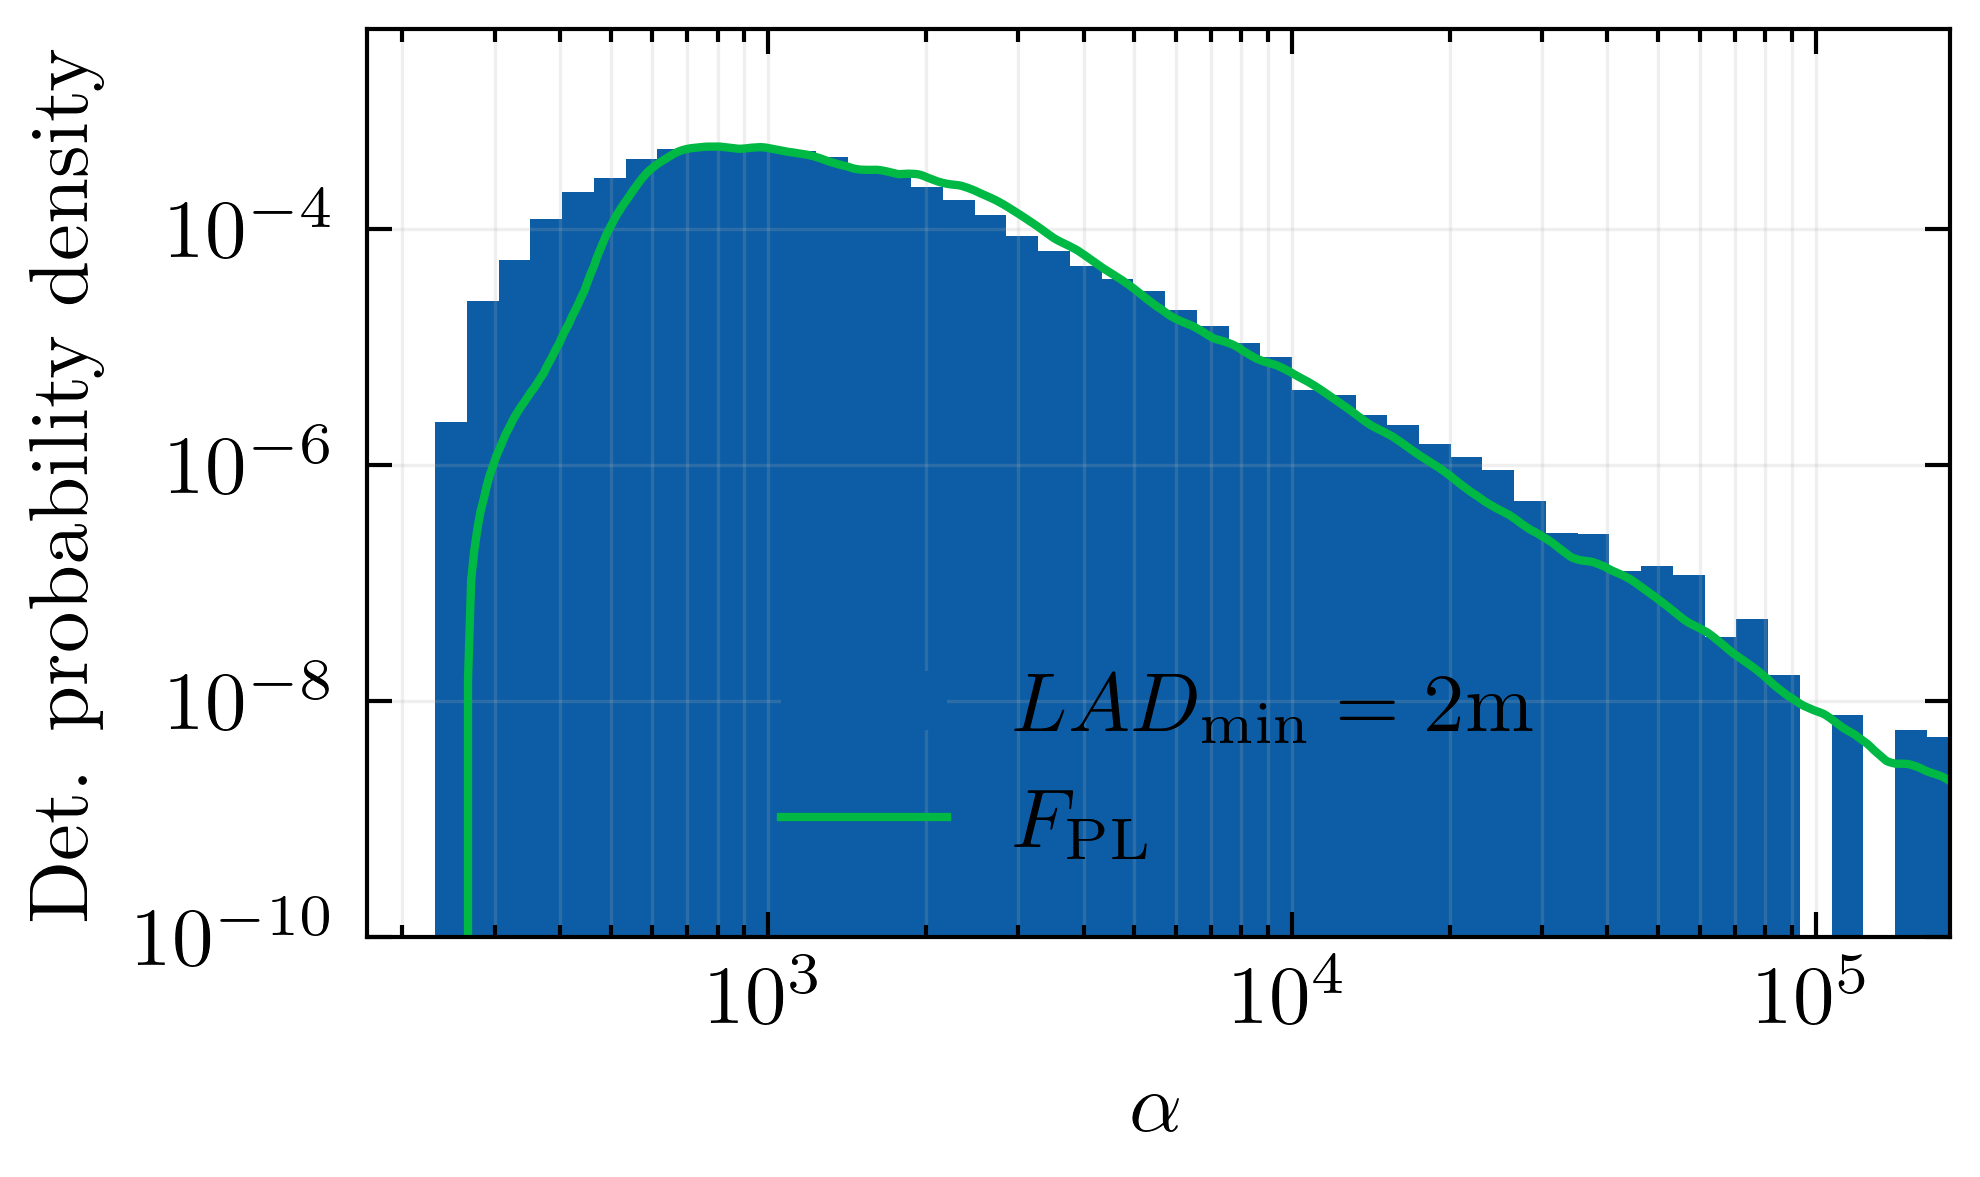

In [8]:
# 1.6290 0.6006 for LAD min = 2
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_alphas_best_S,
                           alphas_hist, density = True, label = rf"$LAD_{{\text{{min}}}} = {fit.LAD_min}$m")

fit_params = PowerLawFitParams(*mle_model.params)
# fit_params = PowerLawFitParams(q=2, g=100)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_S_function), label = r"$F_{\text{PL}}$")

plt.ylim(1e-10, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
# plt.savefig(f".plots/PL_fit_LAS_gt_{fit.LAD_min}m.png")
plt.show()

In [5]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/PowerLaw")

while True:
    df = fit.MultiMLEFit(
        optimize_params=PowerLawFitParams(q=1.63, g=1.8),
        numb_runs=20,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"
    filename.parent.mkdir(parents=True, exist_ok=True)

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\power_law_fitting.py:46: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
MultiMLE fit running:   5%|▌         | 1/20 [00:33<10:32, 33.28s/it]C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\power_law_fitting.py:46: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or

KeyboardInterrupt: 